# Exploration des données (EDA)

## 0.import libraries

In [36]:
from pydoc import describe

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading raw file

In [37]:
df = pd.read_csv('../data/raw/store-data.csv', encoding='latin1')
display(df)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10059,1281,CA-2016-160815,9/5/2016,9/6/2016,First Class,TR-21325,TOBY RITTER,Consumer,United States,Cedar Rapids,...,52402.0,Central,TEC-PH-10003505,Technology,Phones,Geemarc AmpliPOWER60,278.4000,3.0,0.00,80.7360
10060,7699,CA-2017-151799,12/14/2017,12/18/2017,Standard Class,BF-11170,BEN FERRER,Home Office,United States,Lawrence,...,1841.0,East,OFF-ST-10002790,Office Supplies,Storage,Safco Industrial Shelving,73.8500,1.0,0.00,2.2155
10061,8597,CA-2014-111934,5/5/2014,5/7/2014,First Class,GD-14590,GIULIETTA DORTCH,Corporate,United States,Arlington,...,22204.0,South,OFF-PA-10000474,Office Supplies,Paper,Easy-staple paper,35.4400,1.0,0.00,16.6568
10062,4962,CA-2014-156587,3/7/2014,3/8/2014,First Class,AB-10015,NaN,Consumer,United States,Seattle,...,98103.0,West,FUR-CH-10004477,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",48.7120,1.0,0.20,5.4801


## Types, memory and unique value

In [38]:
print("shape\n")
print(df.shape)
print("\nData Types:\n")
print(df.dtypes)
print("\nunique:\n")
print(df.nunique())


shape

(10064, 21)

Data Types:

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code          str
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

unique:

Row ID           9994
Order ID         5009
Order Date       1495
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     810
Segment             6
Country             1
City              633
State              86
Postal Code       705
Region              4
Product ID       1862
Category            6
Sub-Category       17
Product Name     1850
Sales            5738
Quantity           15


the shape is (10_064) and Row ID is 9994 it means there is duplicated

## Missing values

In [39]:
missing = df.isnull().sum()
print(missing[missing > 0])

Ship Date        101
Ship Mode        301
Customer Name    351
Postal Code      200
Sales            201
Quantity         199
dtype: int64


## Duplicates

In [40]:
line_duplicated = df.duplicated().sum()
print(f"whole line duplicated: ({line_duplicated})")

row_duplicated = df['Row ID'].duplicated().sum()
print(f"Row ID duplicated: ({row_duplicated})")

whole line duplicated: (34)
Row ID duplicated: (70)


## Descriptive statistics

In [50]:
descriptive_statistics = df.describe()

display(descriptive_statistics)

,Row ID,Sales,Quantity,Discount,Profit
count,10064.000000,9.863000e+03,9865.000000,10064.000000,10064.000000
mean,4994.397059,1.950322e+03,3.780233,0.157501,28.571309
std,2885.848580,4.410673e+04,2.240134,0.210586,233.509461
min,1.000000,4.440000e-01,-5.000000,0.000000,-6599.978000
25%,2496.750000,1.729000e+01,2.000000,0.000000,1.724800
50%,4989.500000,5.450000e+01,3.000000,0.200000,8.643600
75%,7494.250000,2.107600e+02,5.000000,0.200000,29.331600
max,9994.000000,1.131924e+06,14.000000,1.500000,8399.976000


### sales_by_segment

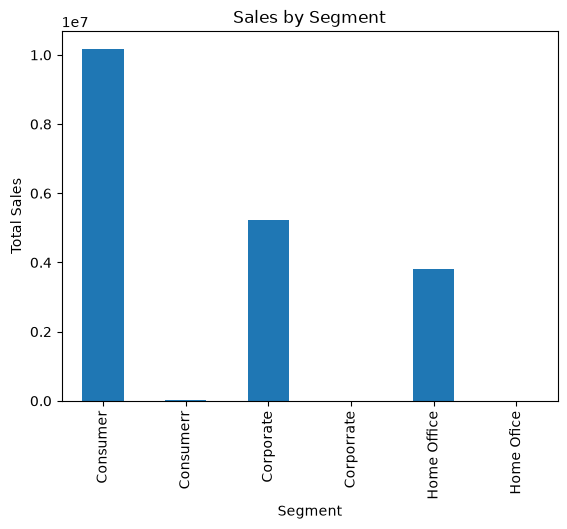

In [74]:
sales_by_segment = df.groupby('Segment')['Sales'].sum()
sales_by_segment.plot(kind='bar')
plt.title('Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.show()

misspelling Segments

### sales_by_category

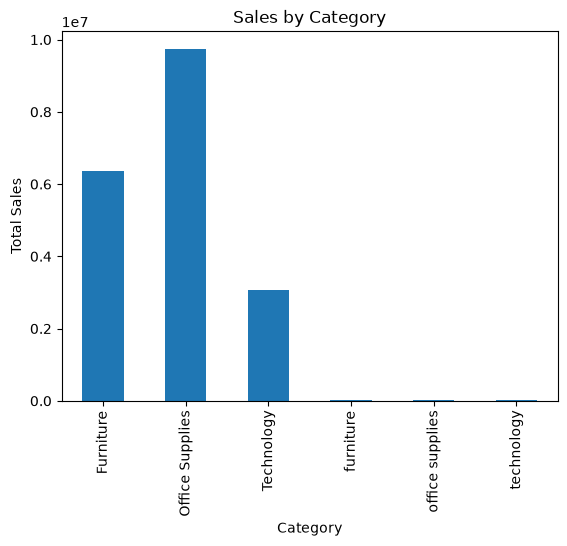

In [75]:

sales_by_category = df.groupby('Category')['Sales'].sum()
sales_by_category.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()



## order ID

In [89]:
print(df['Order ID'].isna().sum())

0


there is no order ID missing

Order date, ship date and Ship  mode

In [104]:
# order date
# order date missing number
print(df['Order Date'].isna().sum())

#ship date
#ship date missing number
print(df['Ship Date'].isna().sum())

#ship mode
#ship mode missing
print(df['Ship Mode'].isna().sum())

#ship modes unique
print(df['Ship Mode'].unique())

0
101
301
<StringArray>
['Second Class', 'Standard Class', nan, 'First Class', 'Same Day']
Length: 5, dtype: str


In [116]:
# Check the relationship

print(df.groupby('Customer ID')['Customer Name'].nunique())

print(df.groupby('Customer ID')['Segment'].nunique())

Customer ID
AA-10315    1
AA-10375    1
AA-10480    1
AA-10645    1
AB-10015    1
           ..
XP-21865    1
YC-21895    1
YS-21880    1
ZC-21910    1
ZD-21925    1
Name: Customer Name, Length: 793, dtype: int64
Customer ID
AA-10315    1
AA-10375    1
AA-10480    1
AA-10645    1
AB-10015    2
           ..
XP-21865    1
YC-21895    1
YS-21880    1
ZC-21910    1
ZD-21925    1
Name: Segment, Length: 793, dtype: int64


In [117]:
#city state and postal code

print(df['City'].isna().sum())
print(df['State'].isna().sum())
print(df['Postal Code'].isna().sum())


0
0
200


i will fix only the misspelling fields

In [126]:
# category, sub_category, product id, and product name

print(df['Category'].isna().sum())
print(df['Sub-Category'].isna().sum())
print(df['Product Name'].isna().sum())
print(df['Product ID'].isna().sum())

check = df.groupby('Product ID')['Product Name'].nunique()

print(check)

print(check.value_counts())

check = df.groupby('Category')['Sub-Category'].unique()

print(check)

check = df['Sub-Category'].unique()

print(check)

0
0
0
0
Product ID
FUR-BO-10000112    1
FUR-BO-10000330    1
FUR-BO-10000362    1
FUR-BO-10000468    1
FUR-BO-10000711    1
                  ..
TEC-PH-10004912    1
TEC-PH-10004922    1
TEC-PH-10004924    1
TEC-PH-10004959    1
TEC-PH-10004977    1
Name: Product Name, Length: 1862, dtype: int64
Product Name
1    1830
2      32
Name: count, dtype: int64
Category
Furniture                   [Bookcases, Chairs, Tables, Furnishings]
Office Supplies    [Labels, Storage, Art, Binders, Appliances, Pa...
Technology                  [Phones, Accessories, Machines, Copiers]
furniture                   [Bookcases, Tables, Chairs, Furnishings]
office supplies    [Binders, Paper, Labels, Envelopes, Appliances...
technology                                     [Accessories, Phones]
Name: Sub-Category, dtype: object
<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Acce

need to fix the Product IDs have 2 different Product Names.

category problem misspelling